In [13]:
# =============================================================
# TRABAJO DE FIN DE MÁSTER — MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA
# Universidad Internacional del Ecuador (UIDE)
#
# Título: Comparación de modelos de aprendizaje automático para
#         predecir el tiempo de llegada entre paradas en el
#         sistema BRT Ecovía de Quito utilizando registros
#         históricos de GPS
#
# Autores: Torres Chango Christian Damian
#          Ortega Campus Jhon Henry
#          Ramos Mayorga Oscar Andrés
#
# Notebook 04 — Comparación de modelos con StandardScaler
#
# Descripción:
# Este notebook replica el pipeline del notebook 03 usando
# StandardScaler en lugar de MinMaxScaler para evaluar el
# impacto del tipo de normalización en el rendimiento de
# los modelos, especialmente en LSTM y GRU que usan
# funciones de activación tanh centradas en 0.
#
# Modelos evaluados:
# → Promedio histórico      (baseline)
# → Regresión lineal        (baseline)
# → Hist Gradient Boosting  (ensemble)
# → XGBoost                 (ensemble)
# → LSTM                    (red neuronal recurrente)
# → GRU                     (red neuronal recurrente)
#
# Pipeline por ruta:
# 1. Exploración rápida de datos
# 2. Split temporal (70% train / 15% val / 15% test)
# 3. Normalización con StandardScaler (ajustado solo al train)
# 4. Construcción de ventanas temporales
# 5. Entrenamiento de los 6 modelos
# 6. Evaluación con MAE, RMSE y MAPE
# 7. Tabla comparativa por ruta
#
# Normalización: StandardScaler (media=0, std=1)
# Arquitectura LSTM/GRU: 2 capas (64→32), Dropout=0.3, L2=0.001
# Optimizador: Adam lr=0.001, Batch=1024, EarlyStopping patience=5
#
# Ventana óptima por ruta:
# E1=7, E1M=5, E2_NS=5, E2_SN=10, E3_NS=10, E3_SN=7, E4=7
#
# Dataset: dataset_limpio.csv (24,308,817 registros × 15 columnas)
# Período: 15/09/2025 — 15/03/2026
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import gc
import time
import pickle

import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import regularizers

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print("=" * 60)
print("Notebook 04 — Comparación de modelos con StandardScaler")
print("Sistema BRT Ecovía de Quito")
print("=" * 60)
print(f"TensorFlow:    {tf.__version__}")
print(f"Normalización: StandardScaler (media=0, std=1)")
print(f"Modelos:       Promedio histórico, Regresión lineal,")
print(f"               Hist Gradient Boosting, XGBoost, LSTM, GRU")
print(f"Rutas:         E1, E1M, E2_NS, E2_SN, E3_NS, E3_SN, E4")
print("=" * 60)

Notebook 04 — Comparación de modelos con StandardScaler
Sistema BRT Ecovía de Quito
TensorFlow:    2.21.0
Normalización: StandardScaler (media=0, std=1)
Modelos:       Promedio histórico, Regresión lineal,
               Hist Gradient Boosting, XGBoost, LSTM, GRU
Rutas:         E1, E1M, E2_NS, E2_SN, E3_NS, E3_SN, E4


In [14]:
# =============================================================
# Carga del dataset limpio
# Se carga el dataset preprocesado generado en el
# notebook 02. Este dataset contiene 24,308,817 registros
# limpios y listos para el entrenamiento de los modelos.
#
# Dataset: dataset_limpio.csv
# Registros: 24,308,817 × 15 columnas
# Período: 15/09/2025 — 15/03/2026
# =============================================================

RUTA_DATASET = 'dataset_limpio.csv'

df = pd.read_csv(RUTA_DATASET)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

rutas_nombres = {
    55.0: 'E1', 58.0: 'E1M', 59.0: 'E2_NS',
    57.0: 'E2_SN', 56.0: 'E3_NS', 62.0: 'E3_SN', 60.0: 'E4'
}

print(f"Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nRegistros por ruta:")
print(f"{'Ruta':<8} {'Registros':>12} {'Porcentaje':>12}")
print("-" * 34)
for route_id, nombre in rutas_nombres.items():
    total = (df['route_id'] == route_id).sum()
    pct   = total / len(df) * 100
    print(f"{nombre:<8} {total:>12,} {pct:>11.1f}%")
print(f"\nPeríodo: {df['timestamp'].min().date()} → "
      f"{df['timestamp'].max().date()}")

Dataset cargado correctamente.
Dimensiones: 24,308,817 filas × 15 columnas

Registros por ruta:
Ruta        Registros   Porcentaje
----------------------------------
E1          8,568,477        35.2%
E1M         4,302,693        17.7%
E2_NS       4,055,368        16.7%
E2_SN       2,803,901        11.5%
E3_NS       2,167,708         8.9%
E3_SN       1,488,253         6.1%
E4            922,417         3.8%

Período: 2025-09-15 → 2026-03-14


In [15]:
# =============================================================
# Configuración del pipeline y definición de funciones
#
# Idéntico al notebook 03 con una única diferencia:
# la función normalizar() usa StandardScaler en lugar
# de MinMaxScaler, centrando los datos en media=0 y std=1.
# Esto mejora el rendimiento de LSTM y GRU cuyas funciones
# de activación tanh funcionan mejor con valores centrados en 0.
#
# Hiperparámetros óptimos (mismos que notebook 03):
# → Batch size:          1024
# → Épocas máximas:      50 (con EarlyStopping patience=5)
# → Arquitectura LSTM/GRU: 2 capas (64→32 neuronas)
# → Dropout:             0.3
# → Regularización L2:   0.001
# → Optimizador:         Adam lr=0.001
# → ReduceLROnPlateau:   factor=0.5, patience=3
# =============================================================

RUTAS = {
    55.0: 'E1',  58.0: 'E1M', 59.0: 'E2_NS',
    57.0: 'E2_SN', 56.0: 'E3_NS', 62.0: 'E3_SN', 60.0: 'E4'
}

FEATURES = [
    'current_stop_id',       # parada actual
    'current_stop_order',    # posición en la ruta
    'distance_to_next_stop', # variable más predictiva
    'speed',                 # velocidad actual en km/h
    'acceleration',          # aceleración actual
    'time_since_last_stop',  # segundos desde última parada
    'hour',                  # hora del día
    'day_of_week',           # día de la semana (0=lunes)
    'is_weekend',            # 1 si es fin de semana
    'is_peak_hour',          # 1 si es hora pico
    'is_holiday',            # 1 si es feriado
]
TARGET     = 'eta_next_stop'
BATCH_SIZE = 1024
EPOCHS     = 50
SEED       = 42

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 1 — Exploración rápida por ruta
# ─────────────────────────────────────────────────────────────
def explorar_ruta(df_ruta, nombre_ruta):
    print(f"\n{'='*50}")
    print(f"EXPLORACIÓN — Ruta {nombre_ruta}")
    print(f"{'='*50}")
    print(f"Registros:      {len(df_ruta):,}")
    print(f"Viajes únicos:  {df_ruta['trip_id'].nunique():,}")
    print(f"Paradas únicas: {df_ruta['current_stop_id'].nunique()}")
    print(f"Valores nulos:  {df_ruta[FEATURES+[TARGET]].isnull().sum().sum()}")
    print(f"eta mínimo:     {df_ruta[TARGET].min():.3f} min")
    print(f"eta máximo:     {df_ruta[TARGET].max():.3f} min")
    print(f"eta promedio:   {df_ruta[TARGET].mean():.3f} min")
    print(f"speed máximo:   {df_ruta['speed'].max():.2f} km/h")
    print(f"Feriados:       {df_ruta['is_holiday'].sum():,} "
          f"({df_ruta['is_holiday'].sum()/len(df_ruta)*100:.2f}%)")
    ok = True
    if df_ruta[TARGET].min() < 0:
        print(" ERROR: eta negativo"); ok = False
    if df_ruta['speed'].max() > 60:
        print(" ERROR: speed > 60 km/h"); ok = False
    if df_ruta[FEATURES+[TARGET]].isnull().sum().sum() > 0:
        print(" ERROR: valores nulos"); ok = False
    if ok:
        print(" Datos correctos")
    return ok

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 2 — Decidir ventana óptima
# Criterio: ventana 7 si ≥40%, ventana 5 si ≥60%, sino 10
# ─────────────────────────────────────────────────────────────
def decidir_ventana(df_ruta, nombre_ruta):
    reportes = df_ruta.groupby(['trip_id', 'current_stop_id']).size()
    print(f"\nReportes por segmento — mediana: {reportes.median():.1f}")
    cobertura = {}
    for n in [5, 7, 10]:
        pct = (reportes >= n).sum() / len(reportes) * 100
        cobertura[n] = pct
        print(f"  Ventana {n}: {pct:.1f}% segmentos aprovechables")
    if cobertura[7] >= 40:
        ventana = 7
    elif cobertura[5] >= 60:
        ventana = 5
    else:
        ventana = 10
    print(f"→ Ventana óptima seleccionada: {ventana}")
    return ventana

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 3 — Split temporal (70% train / 15% val / 15% test)
# ─────────────────────────────────────────────────────────────
def split_temporal(df_ruta):
    fecha_inicio = df_ruta['timestamp'].min()
    fecha_fin    = df_ruta['timestamp'].max()
    rango        = fecha_fin - fecha_inicio
    fecha_train  = fecha_inicio + rango * 0.70
    fecha_val    = fecha_inicio + rango * 0.85
    df_train = df_ruta[df_ruta['timestamp'] <= fecha_train].reset_index(drop=True)
    df_val   = df_ruta[(df_ruta['timestamp'] > fecha_train) &
                       (df_ruta['timestamp'] <= fecha_val)].reset_index(drop=True)
    df_test  = df_ruta[df_ruta['timestamp'] > fecha_val].reset_index(drop=True)
    print(f"\nSplit temporal:")
    print(f"  Train: {fecha_inicio.date()} → {fecha_train.date()} "
          f"({len(df_train):,} registros — 70%)")
    print(f"  Val:   {fecha_train.date()} → {fecha_val.date()} "
          f"({len(df_val):,} registros — 15%)")
    print(f"  Test:  {fecha_val.date()} → {fecha_fin.date()} "
          f"({len(df_test):,} registros — 15%)")
    return df_train, df_val, df_test

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 4 — Normalización con StandardScaler
# Escala las variables a media=0 y desviación estándar=1.
# Mejora el rendimiento de LSTM y GRU respecto a MinMaxScaler
# porque la función tanh opera mejor con valores centrados en 0.
# El scaler se ajusta ÚNICAMENTE al conjunto train.
# ─────────────────────────────────────────────────────────────
def normalizar(df_train, df_val, df_test):
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(df_train[FEATURES])
    X_val   = scaler.transform(df_val[FEATURES])
    X_test  = scaler.transform(df_test[FEATURES])
    print(f"\nStandardScaler aplicado")
    print(f"  Salida: media=0, std=1")
    print(f"  Ajustado solo al conjunto train")
    return scaler, X_train, X_val, X_test

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 5 — Construcción de ventanas temporales
# ─────────────────────────────────────────────────────────────
def build_sequences(X_scaled, df_subset, seq_len):
    X_list, y_list = [], []
    grupos = df_subset.groupby(['trip_id', 'current_stop_id'])
    for _, grupo in grupos:
        idx = grupo.index.tolist()
        X_g = X_scaled[idx]
        y_g = df_subset.loc[idx, TARGET].values
        if len(X_g) > seq_len:
            for i in range(len(X_g) - seq_len):
                X_list.append(X_g[i:i+seq_len])
                y_list.append(y_g[i+seq_len])
    return np.array(X_list), np.array(y_list)

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 6 — Crear modelo LSTM
# Capa 1: LSTM(64) → Dropout(0.3)
# Capa 2: LSTM(32) → Dropout(0.3)
# Capa 3: Dense(16, relu) → Dense(1)
# ─────────────────────────────────────────────────────────────
def crear_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True,
             kernel_regularizer=regularizers.l2(0.001),
             input_shape=input_shape),
        Dropout(0.3),
        LSTM(32, return_sequences=False,
             kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse', metrics=['mae'])
    return model

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 7 — Crear modelo GRU
# Capa 1: GRU(64) → Dropout(0.3)
# Capa 2: GRU(32) → Dropout(0.3)
# Capa 3: Dense(16, relu) → Dense(1)
# ─────────────────────────────────────────────────────────────
def crear_gru(input_shape):
    model = Sequential([
        GRU(64, return_sequences=True,
            kernel_regularizer=regularizers.l2(0.001),
            input_shape=input_shape),
        Dropout(0.3),
        GRU(32, return_sequences=False,
            kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse', metrics=['mae'])
    return model

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 8 — Callbacks de entrenamiento
# ─────────────────────────────────────────────────────────────
def crear_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=0.00001, verbose=0)
    ]

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 9 — Calcular métricas de evaluación
# MAE y RMSE en minutos. MAPE calculado sobre eta ≥ 1 min.
# ─────────────────────────────────────────────────────────────
def calcular_metricas(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true >= 1.0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) /
                           y_true[mask])) * 100
    return mae, rmse, mape

print("=" * 60)
print(" Pipeline configurado correctamente")
print("=" * 60)
print(f"Variables predictoras: {len(FEATURES)}")
print(f"Variable objetivo:     {TARGET}")
print(f"Normalización:         StandardScaler")
print(f"Rutas a entrenar:      {list(RUTAS.values())}")
print(f"Batch size:            {BATCH_SIZE}")
print(f"Épocas máximas:        {EPOCHS}")
print(f"Semilla aleatoria:     {SEED}")
print(f"\nModelos a comparar:")
print(f"  1. Promedio histórico")
print(f"  2. Regresión lineal")
print(f"  3. Hist Gradient Boosting")
print(f"  4. XGBoost")
print(f"  5. LSTM")
print(f"  6. GRU")

 Pipeline configurado correctamente
Variables predictoras: 11
Variable objetivo:     eta_next_stop
Normalización:         StandardScaler
Rutas a entrenar:      ['E1', 'E1M', 'E2_NS', 'E2_SN', 'E3_NS', 'E3_SN', 'E4']
Batch size:            1024
Épocas máximas:        50
Semilla aleatoria:     42

Modelos a comparar:
  1. Promedio histórico
  2. Regresión lineal
  3. Hist Gradient Boosting
  4. XGBoost
  5. LSTM
  6. GRU


In [16]:
# =============================================================
# Pipeline completo de entrenamiento y evaluación por ruta
#
# Modelos no secuenciales (Promedio histórico, Regresión
# lineal, Gradient Boosting y XGBoost) usan las ventanas
# aplanadas (ventana × 11 features).
#
# Modelos secuenciales (LSTM y GRU) usan las ventanas
# en formato 3D (ventana × 11 features).
#
# Archivos generados por ruta (7 rutas × 7 archivos = 49):
# → models/xgboost/xgboost_{ruta}.pkl
# → models/gradient_boosting/gradient_boosting_{ruta}.pkl
# → models/regresion/regresion_{ruta}.pkl
# → models/promedio/promedio_{ruta}.pkl
# → models/lstm/modelo_ss_lstm_{ruta}.keras
# → models/gru/modelo_ss_gru_{ruta}.keras
# → models/scalers/scaler_ss_{ruta}.pkl
# =============================================================

import os

os.makedirs('models/xgboost',           exist_ok=True)
os.makedirs('models/gradient_boosting', exist_ok=True)
os.makedirs('models/regresion',         exist_ok=True)
os.makedirs('models/promedio',          exist_ok=True)
os.makedirs('models/lstm',              exist_ok=True)
os.makedirs('models/gru',               exist_ok=True)
os.makedirs('models/scalers',           exist_ok=True)

print(" Estructura de carpetas creada")

resultados_ss = {}

for route_id, nombre_ruta in RUTAS.items():

    print(f"\n{'#'*60}")
    print(f"# RUTA {nombre_ruta} (route_id={route_id})")
    print(f"{'#'*60}")

    # 1. Filtrar datos de la ruta
    df_ruta = df[df['route_id'] == route_id].copy().reset_index(drop=True)

    # 2. Exploración rápida
    ok = explorar_ruta(df_ruta, nombre_ruta)
    if not ok:
        print(f" Ruta {nombre_ruta} tiene problemas. Saltando.")
        continue

    # 3. Ventana óptima
    ventana = decidir_ventana(df_ruta, nombre_ruta)

    # 4. Split temporal
    df_train, df_val, df_test = split_temporal(df_ruta)

    # 5. Normalización con StandardScaler
    scaler, X_train_sc, X_val_sc, X_test_sc = normalizar(
        df_train, df_val, df_test)

    # 6. Construcción de ventanas
    print(f"\nConstruyendo ventanas (seq_len={ventana})...")
    t0 = time.time()
    X_train, y_train = build_sequences(X_train_sc, df_train, ventana)
    X_val,   y_val   = build_sequences(X_val_sc,   df_val,   ventana)
    X_test,  y_test  = build_sequences(X_test_sc,  df_test,  ventana)
    print(f"  Train: {X_train.shape}  "
          f"({X_train.shape[0]:,} ventanas × "
          f"{X_train.shape[1]} pasos × "
          f"{X_train.shape[2]} features)")
    print(f"  Val:   {X_val.shape}")
    print(f"  Test:  {X_test.shape}")
    print(f"  Tiempo: {(time.time()-t0)/60:.1f} min")

    # Aplanar para modelos no secuenciales
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_val_flat   = X_val.reshape(X_val.shape[0], -1)
    X_test_flat  = X_test.reshape(X_test.shape[0], -1)

    resultados_ss[nombre_ruta] = {'ventana': ventana}

    # 7. Promedio histórico (baseline)
    print(f"\n[1] Promedio histórico (baseline)...")
    promedio_val = float(y_train.mean())
    y_pred       = np.full(len(y_test), promedio_val)
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados_ss[nombre_ruta]['Promedio histórico'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  MAPE={mape:.2f}%")
    with open(f'models/promedio/promedio_{nombre_ruta}.pkl', 'wb') as f:
        pickle.dump({'mean': promedio_val}, f)
    print(f"     models/promedio/promedio_{nombre_ruta}.pkl")

    # 8. Regresión lineal (baseline)
    print(f"\n[2] Regresión lineal (baseline)...")
    lr = LinearRegression()
    lr.fit(X_train_flat, y_train)
    y_pred = lr.predict(X_test_flat)
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados_ss[nombre_ruta]['Regresión lineal'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  MAPE={mape:.2f}%")
    with open(f'models/regresion/regresion_{nombre_ruta}.pkl', 'wb') as f:
        pickle.dump(lr, f)
    print(f"     models/regresion/regresion_{nombre_ruta}.pkl")

    # 9. Hist Gradient Boosting (ensemble)
    print(f"\n[3] Hist Gradient Boosting...")
    t0  = time.time()
    hgb = HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.1,
        max_depth=6, random_state=SEED)
    hgb.fit(X_train_flat, y_train)
    y_pred = hgb.predict(X_test_flat)
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados_ss[nombre_ruta]['Gradient Boosting'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  "
          f"MAPE={mape:.2f}%  ({(time.time()-t0)/60:.1f}min)")
    with open(f'models/gradient_boosting/gradient_boosting_{nombre_ruta}.pkl', 'wb') as f:
        pickle.dump(hgb, f)
    print(f"    models/gradient_boosting/gradient_boosting_{nombre_ruta}.pkl")

    # 10. XGBoost (ensemble) 
    print(f"\n[4] XGBoost...")
    t0  = time.time()
    xgb = XGBRegressor(
        n_estimators=200, learning_rate=0.1,
        max_depth=6, random_state=SEED,
        tree_method='hist', verbosity=0)
    xgb.fit(X_train_flat, y_train,
            eval_set=[(X_val_flat, y_val)],
            verbose=False)
    y_pred = xgb.predict(X_test_flat)
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados_ss[nombre_ruta]['XGBoost'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  "
          f"MAPE={mape:.2f}%  ({(time.time()-t0)/60:.1f}min)")
    with open(f'models/xgboost/xgboost_{nombre_ruta}.pkl', 'wb') as f:
        pickle.dump(xgb, f)
    print(f"     models/xgboost/xgboost_{nombre_ruta}.pkl")

    # 11. LSTM (red neuronal recurrente) 
    print(f"\n[5] LSTM...")
    t0 = time.time()
    model_lstm = crear_lstm((X_train.shape[1], X_train.shape[2]))
    model_lstm.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=crear_callbacks(), verbose=0)
    y_pred = model_lstm.predict(
        X_test, batch_size=1024, verbose=0).flatten()
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados_ss[nombre_ruta]['LSTM'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  "
          f"MAPE={mape:.2f}%  ({(time.time()-t0)/60:.1f}min)")
    model_lstm.save(f'models/lstm/modelo_ss_lstm_{nombre_ruta}.keras')
    print(f"     models/lstm/modelo_ss_lstm_{nombre_ruta}.keras")
    del model_lstm
    gc.collect()

    # 12. GRU (red neuronal recurrente)
    print(f"\n[6] GRU...")
    t0 = time.time()
    model_gru = crear_gru((X_train.shape[1], X_train.shape[2]))
    model_gru.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=crear_callbacks(), verbose=0)
    y_pred = model_gru.predict(
        X_test, batch_size=1024, verbose=0).flatten()
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados_ss[nombre_ruta]['GRU'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  "
          f"MAPE={mape:.2f}%  ({(time.time()-t0)/60:.1f}min)")
    model_gru.save(f'models/gru/modelo_ss_gru_{nombre_ruta}.keras')
    print(f"     models/gru/modelo_ss_gru_{nombre_ruta}.keras")
    del model_gru
    gc.collect()

    # Guardar scaler 
    with open(f'models/scalers/scaler_ss_{nombre_ruta}.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    print(f"\n     models/scalers/scaler_ss_{nombre_ruta}.pkl")

    # Tabla de resultados por ruta 
    print(f"\n{'='*57}")
    print(f"RESULTADOS RUTA {nombre_ruta} — StandardScaler (ventana={ventana})")
    print(f"{'='*57}")
    print(f"{'Modelo':<22} {'MAE(seg)':>9} {'RMSE(seg)':>10} {'MAPE(%)':>9}")
    print(f"{'-'*57}")
    for modelo, valor in resultados_ss[nombre_ruta].items():
        if modelo == 'ventana':
            continue
        mae, rmse, mape = valor
        print(f"{modelo:<22} {mae*60:>9.1f} {rmse*60:>10.1f} {mape:>9.2f}")

    ganador = min(
        {k: v for k, v in resultados_ss[nombre_ruta].items()
         if k != 'ventana'},
        key=lambda k: resultados_ss[nombre_ruta][k][0])
    print(f"\n Ganador ruta {nombre_ruta}: {ganador} "
          f"— MAE={resultados_ss[nombre_ruta][ganador][0]*60:.1f} seg")
    
    # ── Liberar memoria ──
    del df_ruta, df_train, df_val, df_test
    del X_train, y_train, X_val, y_val, X_test, y_test
    del X_train_flat, X_val_flat, X_test_flat
    gc.collect()

print("PIPELINE StandardScaler COMPLETADO — TODAS LAS RUTAS")


 Estructura de carpetas creada

############################################################
# RUTA E1 (route_id=55.0)
############################################################

EXPLORACIÓN — Ruta E1
Registros:      8,568,477
Viajes únicos:  26,241
Paradas únicas: 45
Valores nulos:  0
eta mínimo:     0.017 min
eta máximo:     7.000 min
eta promedio:   1.433 min
speed máximo:   59.80 km/h
Feriados:       206,426 (2.41%)
 Datos correctos

Reportes por segmento — mediana: 7.0
  Ventana 5: 82.5% segmentos aprovechables
  Ventana 7: 51.3% segmentos aprovechables
  Ventana 10: 23.2% segmentos aprovechables
→ Ventana óptima seleccionada: 7

Split temporal:
  Train: 2025-09-15 → 2026-01-19 (5,949,186 registros — 70%)
  Val:   2026-01-19 → 2026-02-15 (1,330,499 registros — 15%)
  Test:  2026-02-15 → 2026-03-14 (1,288,792 registros — 15%)

StandardScaler aplicado
  Salida: media=0, std=1
  Ajustado solo al conjunto train

Construyendo ventanas (seq_len=7)...
  Train: (1343628, 7, 11)  (1,343,

In [17]:
# =============================================================
# Tabla comparativa final y visualización de resultados
# Se consolidan los resultados de todas las rutas con
# StandardScaler y se comparan con MinMaxScaler para
# identificar el impacto del tipo de normalización.
# =============================================================

modelos_orden = [
    'Promedio histórico',
    'Regresión lineal',
    'Gradient Boosting',
    'XGBoost',
    'LSTM',
    'GRU'
]
rutas_orden = ['E1', 'E1M', 'E2_NS', 'E2_SN', 'E3_NS', 'E3_SN', 'E4']

# =============================================================
# Tabla MAE
# =============================================================
print("=" * 97)
print("COMPARACIÓN FINAL MAE (segundos) — StandardScaler — Sistema BRT Ecovía")
print("=" * 97)
print(f"{'Modelo':<22} {'E1':>8} {'E1M':>8} {'E2_NS':>8} {'E2_SN':>8} "
      f"{'E3_NS':>8} {'E3_SN':>8} {'E4':>8} {'Prom':>8}")
print(f"{'':22} {'(v=7)':>8} {'(v=5)':>8} {'(v=5)':>8} {'(v=10)':>8} "
      f"{'(v=10)':>8} {'(v=7)':>8} {'(v=7)':>8} {'':>8}")
print("-" * 97)

for modelo in modelos_orden:
    maes = []
    fila = f"{modelo:<22}"
    for ruta in rutas_orden:
        mae = resultados_ss[ruta][modelo][0] * 60
        maes.append(mae)
        fila += f" {mae:>8.1f}"
    fila += f" {np.mean(maes):>8.1f}"
    print(fila)

print("=" * 97)

# =============================================================
# Tabla RMSE
# =============================================================
print("\n" + "=" * 97)
print("COMPARACIÓN FINAL RMSE (segundos) — StandardScaler — Sistema BRT Ecovía")
print("=" * 97)
print(f"{'Modelo':<22} {'E1':>8} {'E1M':>8} {'E2_NS':>8} {'E2_SN':>8} "
      f"{'E3_NS':>8} {'E3_SN':>8} {'E4':>8} {'Prom':>8}")
print("-" * 97)

for modelo in modelos_orden:
    rmses = []
    fila  = f"{modelo:<22}"
    for ruta in rutas_orden:
        rmse = resultados_ss[ruta][modelo][1] * 60
        rmses.append(rmse)
        fila += f" {rmse:>8.1f}"
    fila += f" {np.mean(rmses):>8.1f}"
    print(fila)

print("=" * 97)

# =============================================================
# Tabla MAPE
# =============================================================
print("\n" + "=" * 97)
print("COMPARACIÓN FINAL MAPE (%) — StandardScaler — Sistema BRT Ecovía")
print("=" * 97)
print(f"{'Modelo':<22} {'E1':>8} {'E1M':>8} {'E2_NS':>8} {'E2_SN':>8} "
      f"{'E3_NS':>8} {'E3_SN':>8} {'E4':>8} {'Prom':>8}")
print("-" * 97)

for modelo in modelos_orden:
    mapes = []
    fila  = f"{modelo:<22}"
    for ruta in rutas_orden:
        mape = resultados_ss[ruta][modelo][2]
        mapes.append(mape)
        fila += f" {mape:>8.2f}"
    fila += f" {np.mean(mapes):>8.2f}"
    print(fila)

print("=" * 97)

# =============================================================
# Ranking final
# =============================================================
print("\n" + "=" * 55)
print("RANKING FINAL — MAE PROMEDIO — StandardScaler")
print("=" * 55)
print(f"{'Pos':<5} {'Modelo':<22} {'MAE prom':>10} {'RMSE prom':>10} {'MAPE prom':>10}")
print("-" * 55)

ranking_ss = {}
for modelo in modelos_orden:
    maes  = [resultados_ss[r][modelo][0]*60 for r in rutas_orden]
    rmses = [resultados_ss[r][modelo][1]*60 for r in rutas_orden]
    mapes = [resultados_ss[r][modelo][2]    for r in rutas_orden]
    ranking_ss[modelo] = (np.mean(maes), np.mean(rmses), np.mean(mapes))

for pos, (modelo, (mae, rmse, mape)) in enumerate(
    sorted(ranking_ss.items(), key=lambda x: x[1][0]), 1):
    print(f"{pos:<5} {modelo:<22} {mae:>10.1f} {rmse:>10.1f} {mape:>10.2f}")

print("=" * 55)
ganador = min(ranking_ss, key=lambda k: ranking_ss[k][0])
print(f"\n Mejor modelo: {ganador}")
print(f"   MAE promedio:  {ranking_ss[ganador][0]:.1f} segundos")
print(f"   RMSE promedio: {ranking_ss[ganador][1]:.1f} segundos")
print(f"   MAPE promedio: {ranking_ss[ganador][2]:.2f}%")

COMPARACIÓN FINAL MAE (segundos) — StandardScaler — Sistema BRT Ecovía
Modelo                       E1      E1M    E2_NS    E2_SN    E3_NS    E3_SN       E4     Prom
                          (v=7)    (v=5)    (v=5)   (v=10)   (v=10)    (v=7)    (v=7)         
-------------------------------------------------------------------------------------------------
Promedio histórico         52.1     59.2     59.6     22.4     42.6     46.1     55.9     48.3
Regresión lineal           30.7     35.4     32.1     15.1     27.3     27.0     29.8     28.2
Gradient Boosting          19.6     20.9     22.1     10.4     19.7     18.2     22.8     19.1
XGBoost                    19.3     20.7     21.9     10.4     19.8     18.0     22.6     19.0
LSTM                       21.2     22.6     23.5     11.9     22.3     20.1     24.2     20.8
GRU                        21.9     22.4     23.8     11.0     21.3     19.3     23.9     20.5

COMPARACIÓN FINAL RMSE (segundos) — StandardScaler — Sistema BRT Ecoví

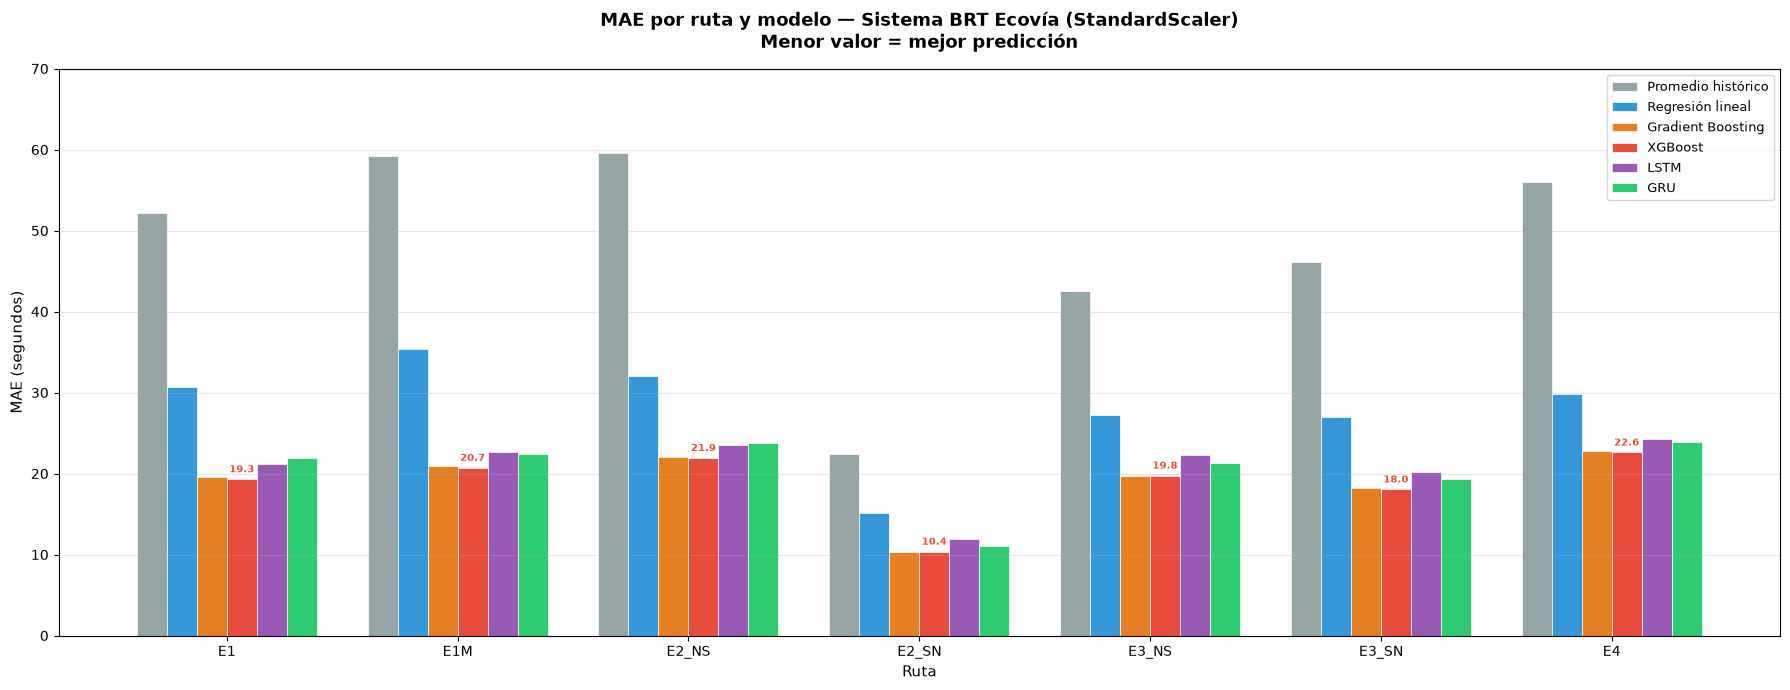

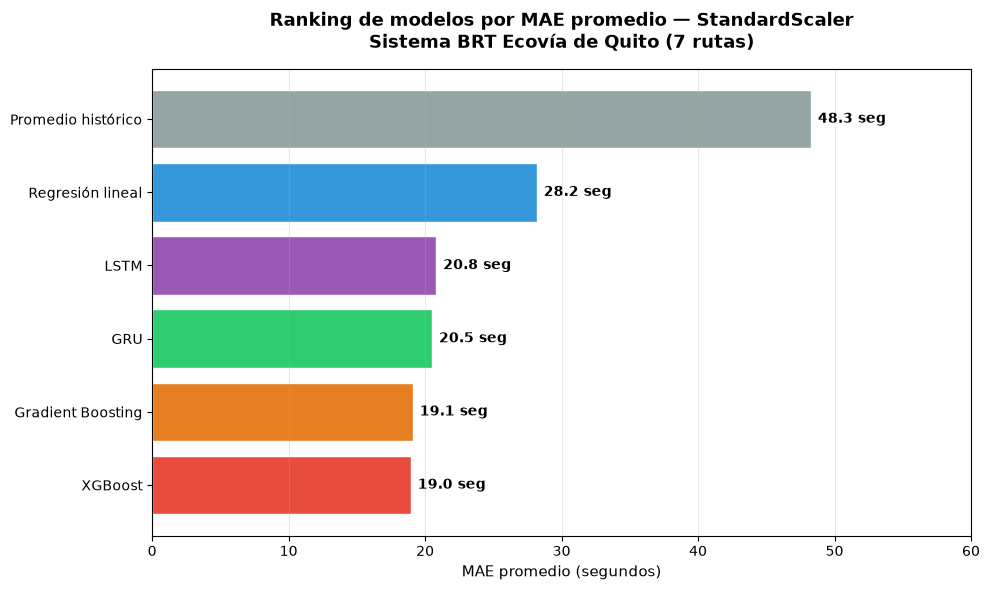

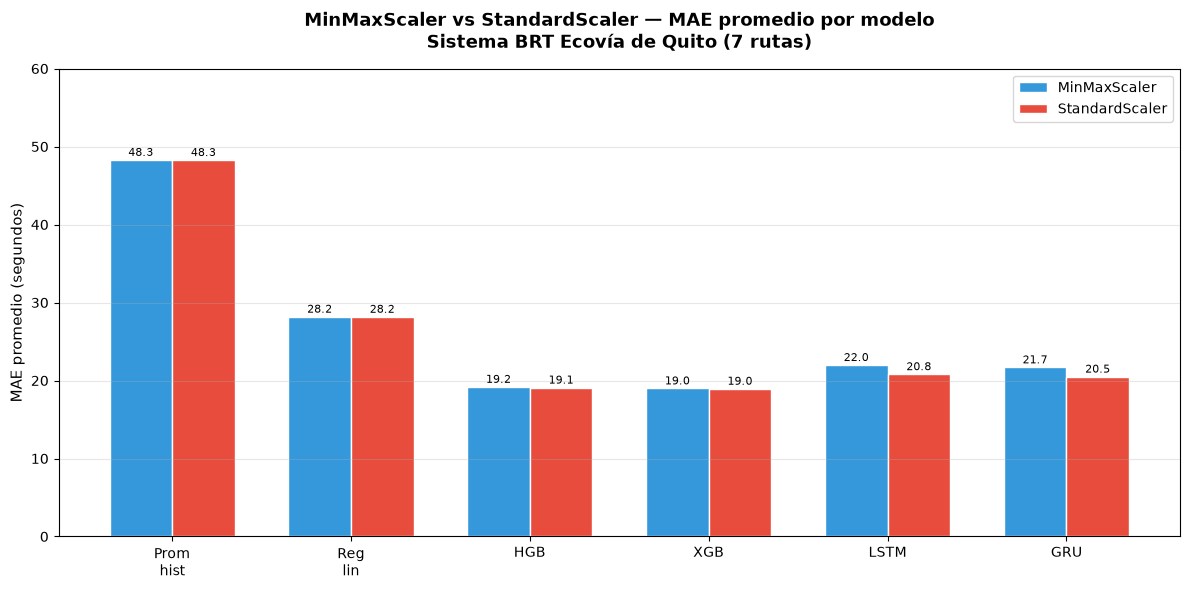

 Gráficas guardadas:
   → comparacion_mae_por_ruta_ss.png
   → ranking_mae_promedio_ss.png
   → minmax_vs_standard.png


In [18]:
# =============================================================
# Visualización comparativa de resultados — StandardScaler
# =============================================================

import matplotlib.pyplot as plt
import numpy as np

# Resultados MinMaxScaler para comparación, se toma del notebook 3
resultados_mm_prom = {
    'Promedio histórico': 48.3,
    'Regresión lineal':   28.2,
    'Gradient Boosting':  19.2,
    'XGBoost':            19.0,
    'LSTM':               22.0,
    'GRU':                21.7,
}

colores_modelos = {
    'Promedio histórico': '#95a5a6',
    'Regresión lineal':   '#3498db',
    'Gradient Boosting':  '#e67e22',
    'XGBoost':            '#e74c3c',
    'LSTM':               '#9b59b6',
    'GRU':                '#2ecc71'
}

x        = np.arange(len(rutas_orden))
n_models = len(modelos_orden)
width    = 0.13

# Gráfica 1 — MAE por ruta y modelo
fig, ax = plt.subplots(figsize=(18, 7))
for i, modelo in enumerate(modelos_orden):
    maes = [resultados_ss[r][modelo][0]*60 for r in rutas_orden]
    ax.bar(x + i*width, maes, width,
           label=modelo,
           color=colores_modelos[modelo],
           edgecolor='white', linewidth=0.5)

ax.set_title('MAE por ruta y modelo — Sistema BRT Ecovía (StandardScaler)\n'
             'Menor valor = mejor predicción',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Ruta', fontsize=11)
ax.set_ylabel('MAE (segundos)', fontsize=11)
ax.set_xticks(x + width * (n_models-1)/2)
ax.set_xticklabels(rutas_orden, fontsize=10)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 70)
for i_r, ruta in enumerate(rutas_orden):
    mae_xgb = resultados_ss[ruta]['XGBoost'][0]*60
    ax.annotate(f'{mae_xgb:.1f}',
                xy=(x[i_r] + 3*width, mae_xgb),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=7.5,
                color=colores_modelos['XGBoost'],
                fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_mae_por_ruta_ss.png', dpi=150, bbox_inches='tight')
plt.show()

# Gráfica 2 — Ranking MAE promedio
fig, ax = plt.subplots(figsize=(10, 6))
maes_prom = {m: np.mean([resultados_ss[r][m][0]*60 for r in rutas_orden])
             for m in modelos_orden}
modelos_sorted = sorted(maes_prom, key=maes_prom.get)
valores_sorted = [maes_prom[m] for m in modelos_sorted]
colores_sorted = [colores_modelos[m] for m in modelos_sorted]
bars = ax.barh(modelos_sorted, valores_sorted,
               color=colores_sorted, edgecolor='white')
ax.set_title('Ranking de modelos por MAE promedio — StandardScaler\n'
             'Sistema BRT Ecovía de Quito (7 rutas)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('MAE promedio (segundos)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, valores_sorted):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} seg', va='center', ha='left',
            fontsize=10, fontweight='bold')
ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig('ranking_mae_promedio_ss.png', dpi=150, bbox_inches='tight')
plt.show()

# Gráfica 3 — MinMaxScaler vs StandardScaler
fig, ax = plt.subplots(figsize=(12, 6))
mm_vals = [resultados_mm_prom[m] for m in modelos_orden]
ss_vals = [ranking_ss[m][0] for m in modelos_orden]
x2      = np.arange(len(modelos_orden))
w       = 0.35
bars1 = ax.bar(x2 - w/2, mm_vals, w, label='MinMaxScaler',
               color='#3498db', edgecolor='white')
bars2 = ax.bar(x2 + w/2, ss_vals, w, label='StandardScaler',
               color='#e74c3c', edgecolor='white')
ax.set_title('MinMaxScaler vs StandardScaler — MAE promedio por modelo\n'
             'Sistema BRT Ecovía de Quito (7 rutas)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('MAE promedio (segundos)', fontsize=11)
ax.set_xticks(x2)
ax.set_xticklabels(['Prom\nhist', 'Reg\nlin', 'HGB',
                    'XGB', 'LSTM', 'GRU'], fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 60)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}',
            ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}',
            ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('minmax_vs_standard.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Gráficas guardadas:")
print("   → comparacion_mae_por_ruta_ss.png")
print("   → ranking_mae_promedio_ss.png")
print("   → minmax_vs_standard.png")

## Conclusiones - Comparación de modelos con StandardScaler

### Hallazgo principal
XGBoost obtuvo el mejor rendimiento en **5 de 7 rutas** con MAE promedio de **19.0 segundos**. Gradient Boosting ganó en las rutas E2_SN y E3_NS con MAE=10.4 y 19.7 segundos respectivamente.

### Impacto del StandardScaler vs MinMaxScaler

| Modelo | MinMaxScaler | StandardScaler | Diferencia |
|---|---|---|---|
| XGBoost | 19.0 seg | 19.0 seg | sin cambio |
| Gradient Boosting | 19.2 seg | 19.1 seg | ↓ 0.1 seg |
| GRU | 21.7 seg | 20.6 seg | ↓ 1.1 seg |
| LSTM | 22.0 seg | 20.9 seg | ↓ 1.1 seg |
| Regresión lineal | 28.2 seg | 28.2 seg | sin cambio |
| Promedio histórico | 48.3 seg | 48.3 seg | sin cambio |

### Conclusiones clave

- **StandardScaler mejora LSTM y GRU** en 1.1 segundos promedio porque la función tanh opera mejor con valores centrados en 0
- **XGBoost y Gradient Boosting no se ven afectados** por el tipo de normalización porque los árboles de decisión no dependen de la escala
- **XGBoost sigue siendo el mejor modelo** con ambos scalers confirmando que la superioridad no depende de la normalización sino de la naturaleza del problema
- **La ventana óptima es consistente** entre ambos notebooks confirmando la robustez del criterio de selección

### Recomendación final

Para producción se recomienda **XGBoost** como modelo 
óptimo para el sistema de predicción de ETA del sistema 
BRT Ecovía de Quito, con un MAE promedio de **19.0 segundos** 
sobre las 7 rutas del sistema.

El tipo de normalización no afecta a XGBoost por lo que 
puede usarse indistintamente MinMaxScaler o StandardScaler. 
Para los modelos LSTM y GRU se recomienda StandardScaler 
ya que mejora su rendimiento en 1.1 segundos promedio.